# Khám Phá Dữ Liệu Sức Khỏe Tâm Thần — Exploring Mental Health Data

## Giới Thiệu Dự Án

Dự án này lấy cảm hứng từ cuộc thi Kaggle **Exploring Mental Health Data**.  
Mục tiêu chính: **dự đoán liệu một người có bị trầm cảm hay không** (`Depression = 1`) dựa trên dữ liệu khảo sát sức khỏe tâm thần.

| Thông tin | Chi tiết |
|---|---|
| **Biến mục tiêu** | `Depression` (0 = không trầm cảm, 1 = trầm cảm) |
| **Tập huấn luyện** | 140 700 mẫu × 20 cột |
| **Đặc trưng** | Nhân khẩu học, áp lực học tập/công việc, thói quen sinh hoạt, tiền sử gia đình |

## Mục Lục

1. Import Thư Viện & Cấu Hình  
2. Tải Dữ Liệu & Khám Phá Ban Đầu  
3. Phân Tích Khám Phá Dữ Liệu (EDA)  
   - 3.1 Phân tích giá trị thiếu
   - 3.2 Tiền Xử Lý Dữ Liệu & Feature Engineering  
   - 3.3 Phân phối đặc trưng số theo nhãn  
   - 3.4 Tỷ lệ trầm cảm theo đặc trưng phân loại  
   - 3.5 Ma trận tương quan 
4. Xây Dựng Mô Hình — CatBoost  
5. Đánh Giá Mô Hình CatBoost
6. Tối ưu hóa Threshold (Ngưỡng)
7. Đánh giá ROC-AUC & Biểu đồ phân phối
8. Độ Quan Trọng Đặc Trưng  
9. Mô Hình LightGBM & Random Forest  
10. So Sánh Các Mô Hình  
11. Kiểm Tra Chéo (Cross-Validation)  
12. Kết Luận & Hướng Phát Triển

# Import Thư Viện & Cấu Hình


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
%matplotlib inline
sns.set(style="whitegrid")
pd.set_option('display.max_columns', 25)

# Tải Dữ Liệu & Khám Phá Ban Đầu

--- 5 dòng đầu của tập huấn luyện ---


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0



--- Thông tin chi tiết các cột ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction  

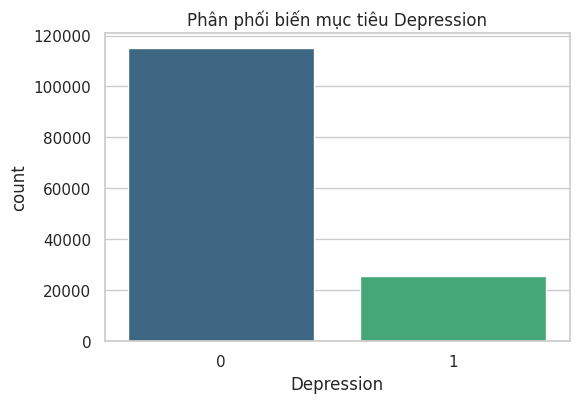

In [2]:
train_df = pd.read_csv('/kaggle/input/datasets/envyy23120093/ptdltm1/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/envyy23120093/ptdltm1/test.csv')

print("--- 5 dòng đầu của tập huấn luyện ---")
display(train_df.head())

print("\n--- Thông tin chi tiết các cột ---")
train_df.info()

plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=train_df, palette='viridis')
plt.title('Phân phối biến mục tiêu Depression')
plt.show()

# Phân Tích Khám Phá Dữ Liệu (EDA)

3.1  PHÂN TÍCH GIÁ TRỊ THIẾU & XỬ LÝ NOISE
                    Số lượng thiếu  Tỷ lệ (%)
Academic Pressure           112803      80.17
Study Satisfaction          112803      80.17
CGPA                        112802      80.17
Profession                   36630      26.03
Work Pressure                27918      19.84
Job Satisfaction             27910      19.84
Dietary Habits                   4       0.00
Degree                           2       0.00
Financial Stress                 4       0.00


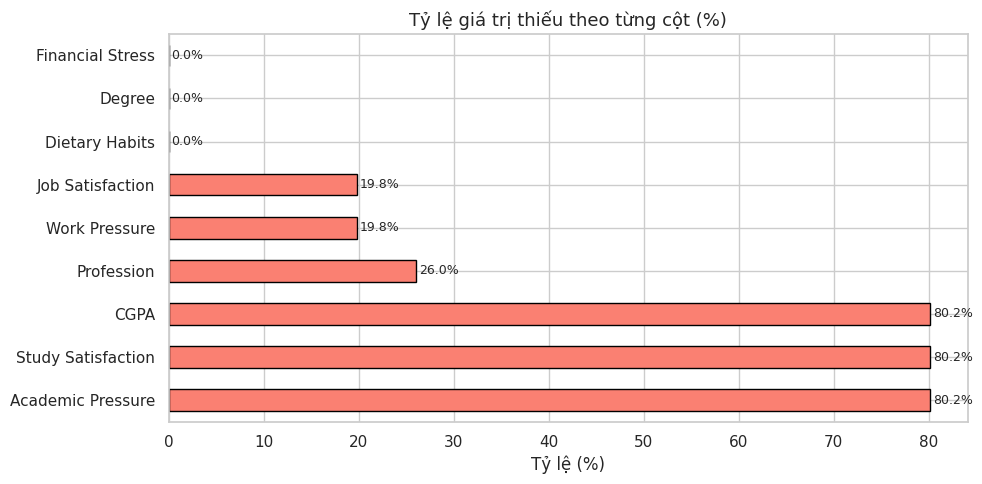


Nhận xét:
  - Academic Pressure / Study Satisfaction / CGPA: ~80% thiếu
    Chỉ dành cho sinh viên
  - Work Pressure / Job Satisfaction: ~20% thiếu
    Chỉ dành cho người đi làm
  - Profession: ~26% thiếu → sinh viên không có nghề nghiệp
    Chiến lược: điền median cho cột số, điền mode cho cột phân loại

--- Kiểm tra các giá trị duy nhất trong cột phân loại ---

Sleep Duration (36 giá trị): ['1-2 hours', '1-3 hours', '1-6 hours', '10-11 hours', '10-6 hours', '2-3 hours', '3-4 hours', '3-6 hours', '35-36 hours', '4-5 hours', '4-6 hours', '40-45 hours', '45', '45-48 hours', '49 hours']...

Dietary Habits (23 giá trị): ['1.0', '2', '3', 'BSc', 'Class 12', 'Electrician', 'Gender', 'Healthy', 'Hormonal', 'Indoor', 'Less Healthy', 'Less than Healthy', 'M.Tech', 'Male', 'Mihir']...

Gender (2 giá trị): ['Female', 'Male']

Working Professional or Student (2 giá trị): ['Student', 'Working Professional']


In [3]:
# ============================================================
# PHẦN 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
# ============================================================

# --- 3.1 Phân tích giá trị thiếu (Missing Value Analysis) ---
print("=" * 60)
print("3.1  PHÂN TÍCH GIÁ TRỊ THIẾU & XỬ LÝ NOISE")
print("=" * 60)

missing     = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Số lượng thiếu': missing,
    'Tỷ lệ (%)': missing_pct
}).query('`Số lượng thiếu` > 0').sort_values('Tỷ lệ (%)', ascending=False)
print(missing_df.to_string())

# Biểu đồ bar chart tỷ lệ thiếu theo cột
plt.figure(figsize=(10, 5))
missing_df['Tỷ lệ (%)'].plot(kind='barh', color='salmon', edgecolor='black')
plt.title('Tỷ lệ giá trị thiếu theo từng cột (%)', fontsize=13)
plt.xlabel('Tỷ lệ (%)')
for i, v in enumerate(missing_df['Tỷ lệ (%)']):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nNhận xét:")
print("  - Academic Pressure / Study Satisfaction / CGPA: ~80% thiếu")
print("    Chỉ dành cho sinh viên")
print("  - Work Pressure / Job Satisfaction: ~20% thiếu")
print("    Chỉ dành cho người đi làm")
print("  - Profession: ~26% thiếu → sinh viên không có nghề nghiệp")
print("    Chiến lược: điền median cho cột số, điền mode cho cột phân loại")

# Kiểm tra noise / giá trị bất thường trong các cột phân loại
print("\n--- Kiểm tra các giá trị duy nhất trong cột phân loại ---")
for col in ['Sleep Duration', 'Dietary Habits', 'Gender',
            'Working Professional or Student']:
    unique_vals = sorted(train_df[col].dropna().unique())
    print(f"\n{col} ({len(unique_vals)} giá trị): {unique_vals[:15]}"
          f"{'...' if len(unique_vals) > 15 else ''}")

In [4]:
# --- 3.2 Tiền xử lí & làm sạch dữ liệu ---
print("=" * 60)
print("3.2 Tiền xử lí & làm sạch dữ liệu")
print("=" * 60)
def preprocess_data(df):
    data = df.copy()
    
    # 1. Chỉ giữ lại 3 giá trị đúng, còn lại chuyển thành NaN
    valid_habits = ['Healthy', 'Moderate', 'Unhealthy']
    data.loc[~data['Dietary Habits'].isin(valid_habits), 'Dietary Habits'] = np.nan
    
    # Sau đó mới thực hiện điền Mode (giá trị xuất hiện nhiều nhất) cho các NaN này
    mode_habit = data['Dietary Habits'].mode()[0]
    data['Dietary Habits'] = data['Dietary Habits'].fillna(mode_habit)

    # 2. Mã hóa Sleep Duration từ dạng văn bản → số (giờ trung bình)
    #    Ánh xạ: 'Less than 5 hours' → 4h, '5-6 hours' → 5.5h, v.v.
    sleep_map = {
        'Less than 5 hours': 4.0,
        '5-6 hours':         5.5,
        '6-7 hours':         6.5,
        '7-8 hours':         7.5,
        'More than 8 hours': 9.0,
    }
    data['Sleep Duration'] = data['Sleep Duration'].map(sleep_map).fillna(6.5)

    # 3. Đảm bảo Work/Study Hours là kiểu số, điền median nếu thiếu
    data['Work/Study Hours'] = pd.to_numeric(data['Work/Study Hours'], errors='coerce')
    data['Work/Study Hours'] = data['Work/Study Hours'].fillna(
        data['Work/Study Hours'].median())

    # 4. Điền giá trị thiếu cho các cột số bằng median
    num_fill_cols = ['Academic Pressure', 'Work Pressure', 'CGPA',
                     'Study Satisfaction', 'Job Satisfaction', 'Financial Stress']
    for col in num_fill_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data[col] = data[col].fillna(data[col].median())

    # 5. Điền giá trị thiếu cho cột phân loại bằng mode
    cat_cols = data.select_dtypes(include=['object']).columns
    for col in cat_cols:
        mode_val = data[col].mode()
        data[col] = data[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

    # 6. Feature Engineering — Tạo đặc trưng mới
    # (a) Tỷ lệ giờ làm/học so với giờ ngủ → chỉ số áp lực thời gian
    #     Công thức: Work_Sleep_Ratio = Work_Hours / (Sleep_Hours + 1)
    data['Work_Sleep_Ratio'] = data['Work/Study Hours'] / (data['Sleep Duration'] + 1)

    # (b) Tổng áp lực: kết hợp áp lực học tập và áp lực công việc
    data['Total_Pressure'] = data['Academic Pressure'] + data['Work Pressure']

    # (c) Tổng hài lòng: kết hợp sự hài lòng về học tập và công việc
    data['Total_Satisfaction'] = data['Study Satisfaction'] + data['Job Satisfaction']

    return data


# --- Áp dụng tiền xử lý ---
print("=== Làm sạch noise ===")
train_processed = preprocess_data(train_df)
print("\n=== Áp dụng cho tập test ===")
test_processed  = preprocess_data(test_df)

print(f"\nTiền xử lý hoàn tất!")
print(f"  Số cột sau feature engineering: {train_processed.shape[1]}")
print("\nKiểm tra Sleep Duration và features mới sau xử lý:")
print(train_processed[['Sleep Duration', 'Work/Study Hours',
                        'Work_Sleep_Ratio', 'Total_Pressure',
                        'Total_Satisfaction']].describe().round(3))

# Xác nhận Dietary Habits sau làm sạch
print("\nDietary Habits sau làm sạch:")
print(train_processed['Dietary Habits'].value_counts())

3.2 Tiền xử lí & làm sạch dữ liệu
=== Làm sạch noise ===

=== Áp dụng cho tập test ===

Tiền xử lý hoàn tất!
  Số cột sau feature engineering: 23

Kiểm tra Sleep Duration và features mới sau xử lý:
       Sleep Duration  Work/Study Hours  Work_Sleep_Ratio  Total_Pressure  \
count      140700.000        140700.000        140700.000      140700.000   
mean            6.427             6.253             0.905           6.027   
std             1.914             3.854             0.628           1.402   
min             4.000             0.000             0.000           4.000   
25%             4.000             3.000             0.400           5.000   
50%             5.500             6.000             0.900           6.000   
75%             7.500            10.000             1.294           7.000   
max             9.000            12.000             2.400           8.000   

       Total_Satisfaction  
count          140700.000  
mean                5.969  
std                 1.40


3.3  PHÂN PHỐI ĐẶC TRƯNG SỐ THEO NHÃN


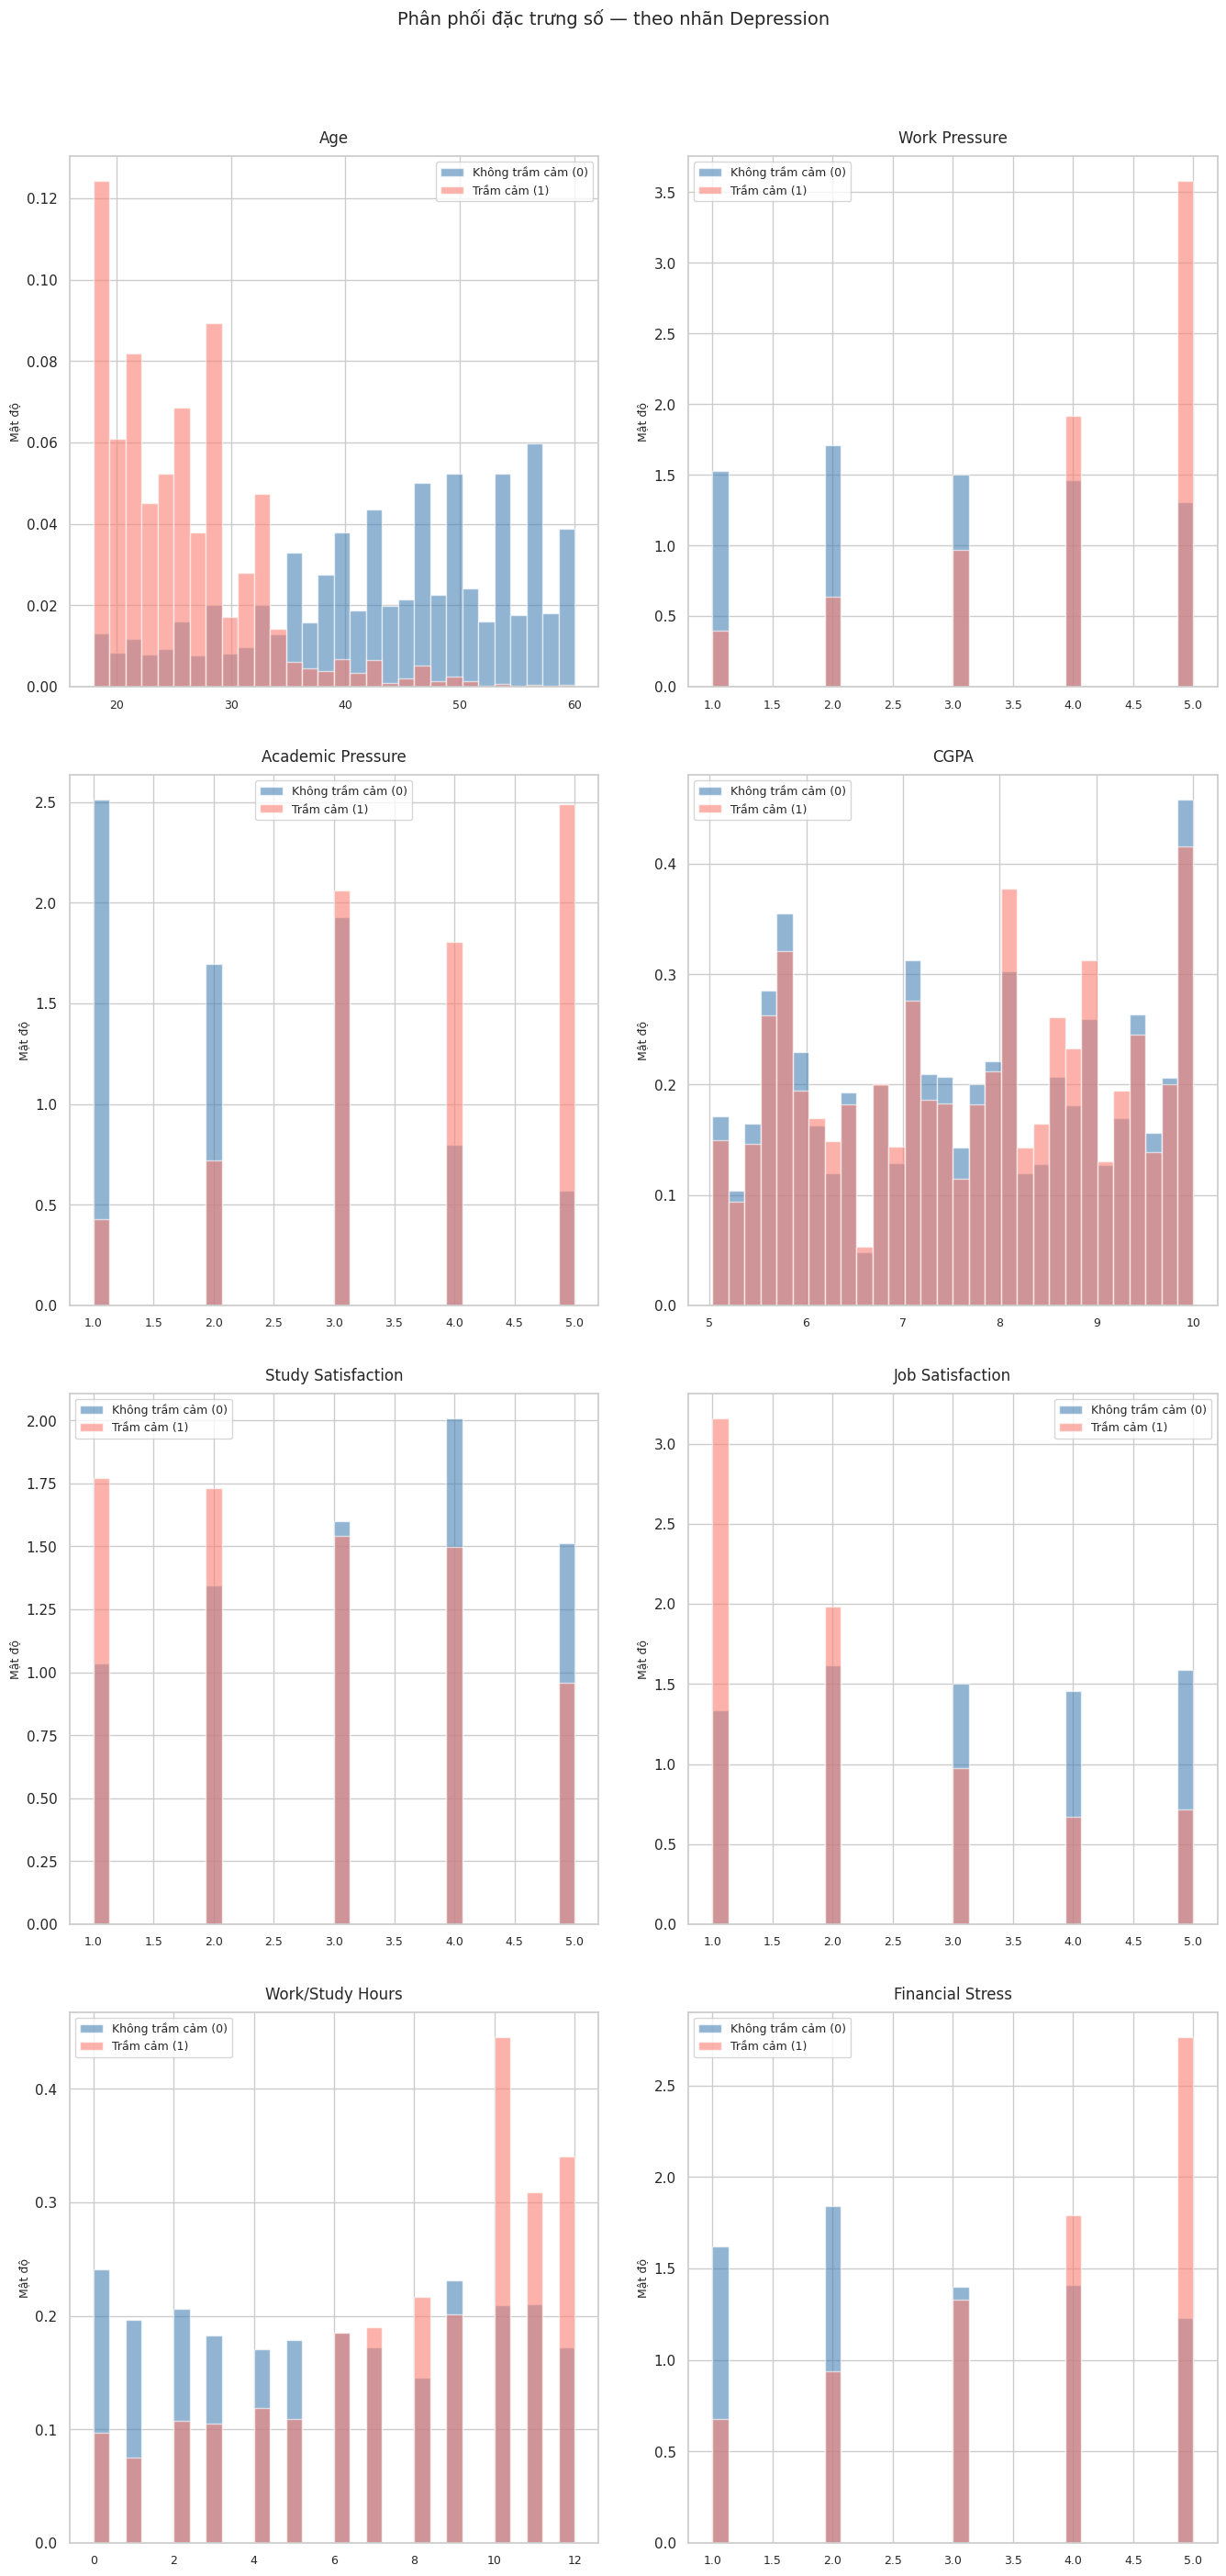


3.4  TỶ LỆ TRẦM CẢM THEO ĐẶC TRƯNG PHÂN LOẠI


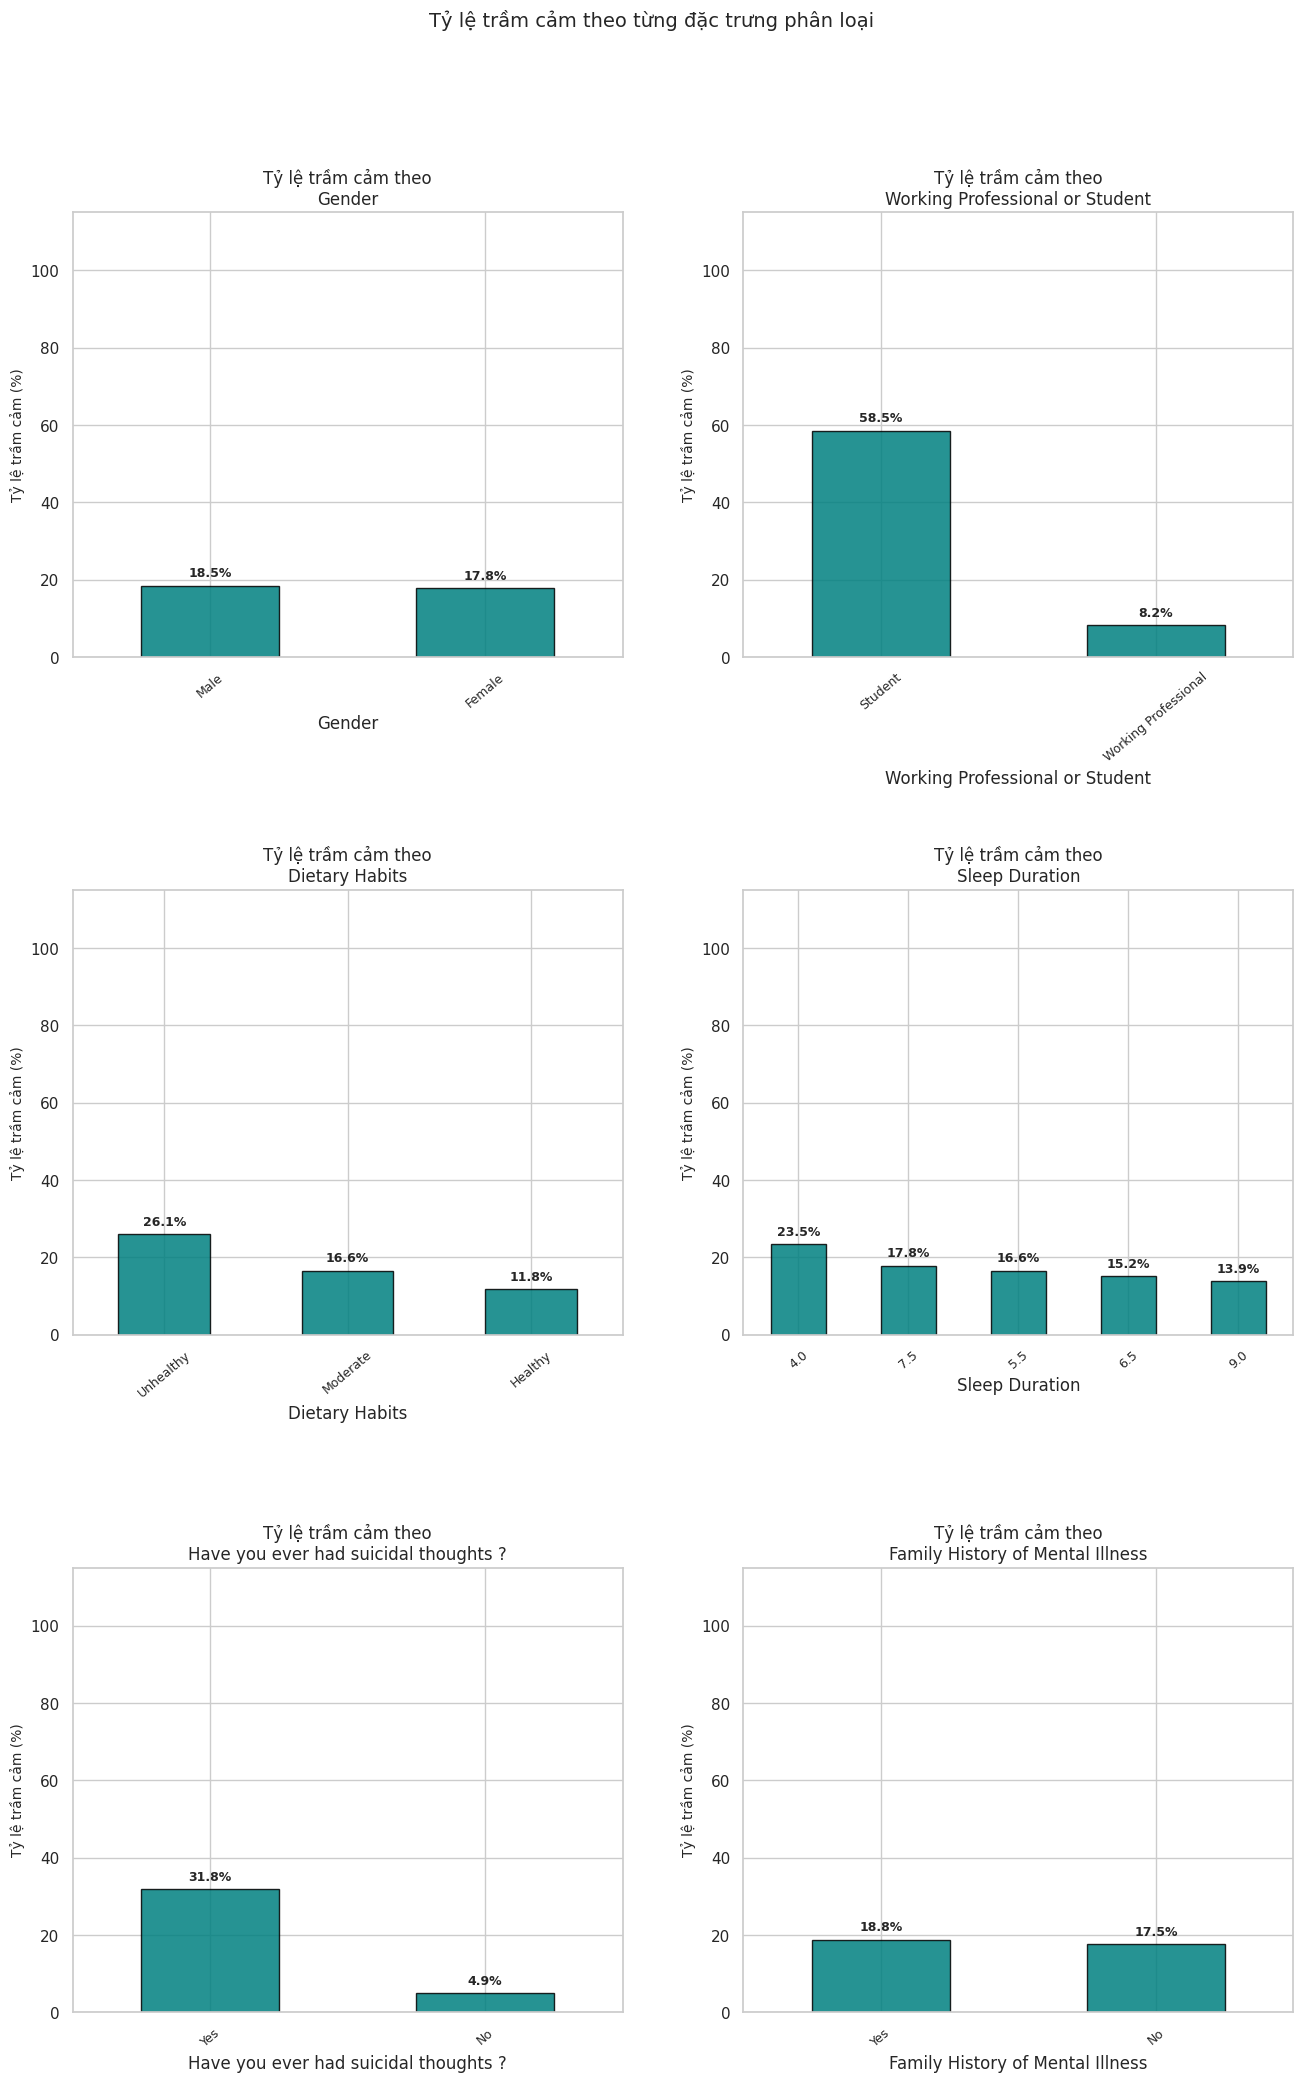

In [5]:
# --- 3.3 Phân phối các đặc trưng số theo nhãn Depression ---
print("\n" + "=" * 60)
print("3.3  PHÂN PHỐI ĐẶC TRƯNG SỐ THEO NHÃN")
print("=" * 60)

num_cols = ['Age', 'Work Pressure', 'Academic Pressure', 'CGPA',
            'Study Satisfaction', 'Job Satisfaction',
            'Work/Study Hours', 'Financial Stress']

fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color, name in [(0, 'steelblue', 'Không trầm cảm (0)'),
                                (1, 'salmon',    'Trầm cảm (1)')]:
        subset = train_df.loc[train_df['Depression'] == label, col].dropna()
        axes[i].hist(subset, alpha=0.6, bins=30,
                     label=name, color=color, density=True)
    axes[i].set_title(col, fontsize=12, pad=10)
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Mật độ', fontsize=9)
    axes[i].tick_params(axis='x', labelsize=9)

plt.suptitle('Phân phối đặc trưng số — theo nhãn Depression',
             fontsize=14, y=1.01)
plt.tight_layout(pad=2.5)
plt.show()

# --- 3.4 Tỷ lệ trầm cảm theo đặc trưng phân loại quan trọng ---
print("\n" + "=" * 60)
print("3.4  TỶ LỆ TRẦM CẢM THEO ĐẶC TRƯNG PHÂN LOẠI")
print("=" * 60)

cat_important = [
    'Gender', 'Working Professional or Student',
    'Dietary Habits', 'Sleep Duration',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 21))
axes = axes.flatten()

for i, col in enumerate(cat_important):
    dep_rate = (train_processed.groupby(col)['Depression']
                .mean()
                .sort_values(ascending=False)
                .head(12) * 100)  
    dep_rate.plot(kind='bar', ax=axes[i],
                  color='teal', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Tỷ lệ trầm cảm theo\n{col}', fontsize=12)
    axes[i].set_ylabel('Tỷ lệ trầm cảm (%)', fontsize=10)
    axes[i].set_ylim(0, 115)
    axes[i].tick_params(axis='x', rotation=40, labelsize=9)
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 1:
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         h + 1.5, f'{h:.1f}%',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold')

plt.suptitle('Tỷ lệ trầm cảm theo từng đặc trưng phân loại',
             fontsize=14, y=1.01)
plt.tight_layout(pad=3.5)
plt.show()


3.5  MA TRẬN TƯƠNG QUAN


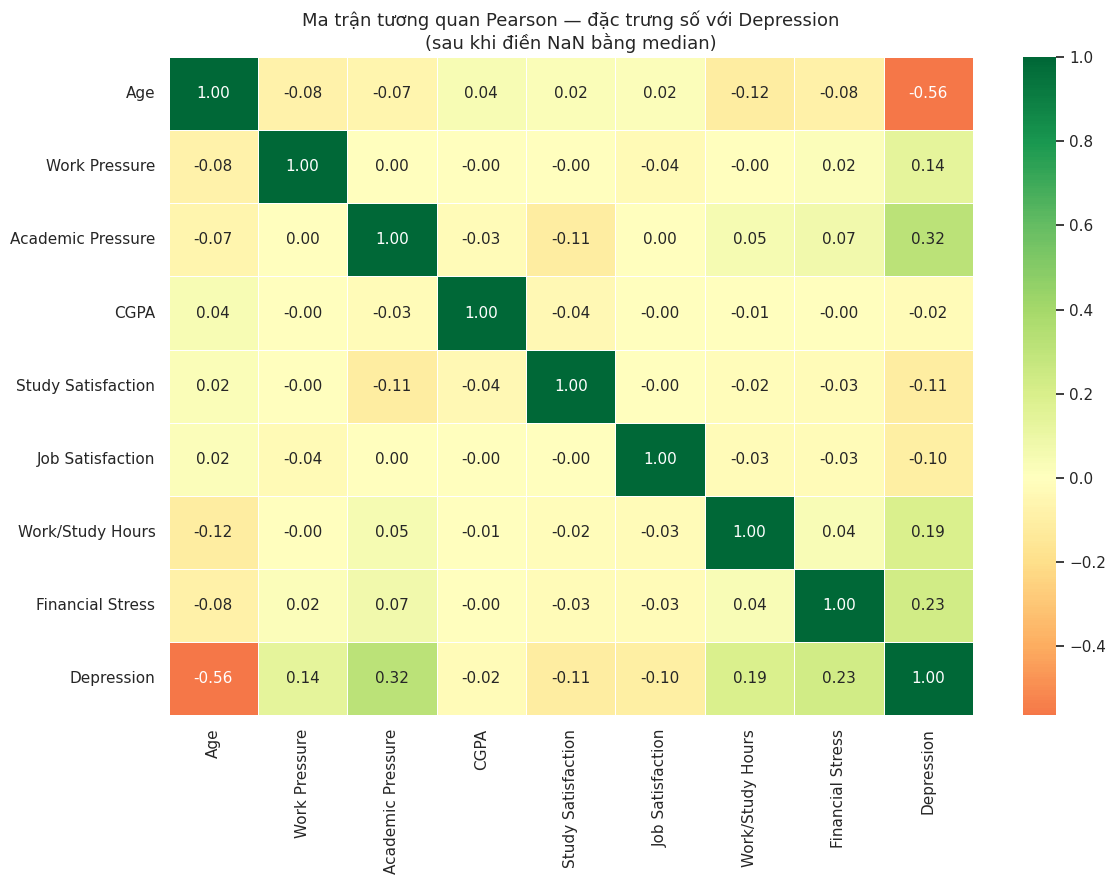


Mức độ tương quan (|r|) với Depression:
  - Age                       |r| = 0.565
  + Academic Pressure         |r| = 0.317
  + Financial Stress          |r| = 0.227
  + Work/Study Hours          |r| = 0.192
  + Work Pressure             |r| = 0.138
  - Study Satisfaction        |r| = 0.114
  - Job Satisfaction          |r| = 0.103
  - CGPA                      |r| = 0.023

→ Age tương quan âm mạnh: người trẻ có tỷ lệ trầm cảm cao hơn.
→ Academic Pressure tương quan dương: áp lực học cao → dễ trầm cảm hơn.


In [6]:
# --- 3.5 Ma trận tương quan (Correlation Matrix) ---
print("=" * 60)
print("3.5  MA TRẬN TƯƠNG QUAN")
print("=" * 60)

corr_cols = ['Age', 'Work Pressure', 'Academic Pressure', 'CGPA',
             'Study Satisfaction', 'Job Satisfaction',
             'Work/Study Hours', 'Financial Stress', 'Depression']

# Tạo bản sao tạm, điền NaN bằng median để tính tương quan đúng
corr_temp = train_df[corr_cols].copy()
for col in corr_cols:
    corr_temp[col] = pd.to_numeric(corr_temp[col], errors='coerce')
    corr_temp[col] = corr_temp[col].fillna(corr_temp[col].median())

corr_matrix = corr_temp.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Ma trận tương quan Pearson — đặc trưng số với Depression\n'
          '(sau khi điền NaN bằng median)', fontsize=13)
plt.tight_layout()
plt.show()

# In tương quan với Depression (sắp xếp giảm dần theo |r|)
print("\nMức độ tương quan (|r|) với Depression:")
top_corr = (corr_matrix['Depression']
            .abs()
            .sort_values(ascending=False)
            .drop('Depression'))
for feat, val in top_corr.items():
    sign = '+' if corr_matrix['Depression'][feat] > 0 else '-'
    print(f"  {sign} {feat:<25} |r| = {val:.3f}")
print("\n→ Age tương quan âm mạnh: người trẻ có tỷ lệ trầm cảm cao hơn.")
print("→ Academic Pressure tương quan dương: áp lực học cao → dễ trầm cảm hơn.")

# Xây Dựng Mô Hình — CatBoost

In [7]:
# Chuẩn bị dữ liệu cho mô hình
X = train_processed.drop(['id', 'Name', 'Depression'], axis=1)
y = train_processed['Depression']
X_test = test_processed.drop(['id', 'Name'], axis=1)

# Xác định danh sách các cột phân loại cho CatBoost
cat_features = list(X.select_dtypes(include=['object']).columns)

# Chia tập dữ liệu để kiểm tra (Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Khởi tạo mô hình CatBoost
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    verbose=100, # In kết quả mỗi 100 vòng lặp [Yêu cầu đồ án]
    random_seed=42
)

# Huấn luyện mô hình
model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 0.6042093	test: 0.6043239	best: 0.6043239 (0)	total: 136ms	remaining: 2m 15s
100:	learn: 0.1510512	test: 0.1552279	best: 0.1552279 (100)	total: 6.76s	remaining: 1m
200:	learn: 0.1466762	test: 0.1527993	best: 0.1527964 (199)	total: 13.1s	remaining: 52s
300:	learn: 0.1443088	test: 0.1522630	best: 0.1522616 (299)	total: 19.2s	remaining: 44.5s
400:	learn: 0.1424268	test: 0.1520568	best: 0.1520394 (396)	total: 25.6s	remaining: 38.2s
500:	learn: 0.1406945	test: 0.1519527	best: 0.1519394 (495)	total: 31.9s	remaining: 31.8s
600:	learn: 0.1391979	test: 0.1518976	best: 0.1518849 (584)	total: 38.4s	remaining: 25.5s
700:	learn: 0.1377107	test: 0.1519791	best: 0.1518849 (584)	total: 44.8s	remaining: 19.1s
800:	learn: 0.1363381	test: 0.1520284	best: 0.1518849 (584)	total: 51.4s	remaining: 12.8s
900:	learn: 0.1350702	test: 0.1520607	best: 0.1518849 (584)	total: 58s	remaining: 6.38s
999:	learn: 0.1338249	test: 0.1520979	best: 0.1518849 (584)	total: 1m 4s	remaining: 0us

bestTest = 0.15188485

CatBoostClassifier(cat_features=['Gender', 'City', 'Working Professional or Student', 'Profession', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'], depth=6, iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

# Đánh Giá Mô Hình CatBoost

In [8]:
# Dự đoán trên tập validation
y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"\nĐộ chính xác (Accuracy) trên tập Validation: {acc:.4f}")
print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_val, y_pred))

# Dự đoán trên tập Test để nộp bài
test_preds = model.predict(X_test)

# Tạo file submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'Depression': test_preds
})
submission.to_csv('submission.csv', index=False)
print("\nĐã lưu file submission.csv thành công!")


Độ chính xác (Accuracy) trên tập Validation: 0.9388

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23027
           1       0.85      0.81      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.90     28140
weighted avg       0.94      0.94      0.94     28140


Đã lưu file submission.csv thành công!


# Tối ưu hóa Threshold (Ngưỡng)

Threshold tốt nhất: 0.39
F1-Score cao nhất trên tập Validation: 0.8330


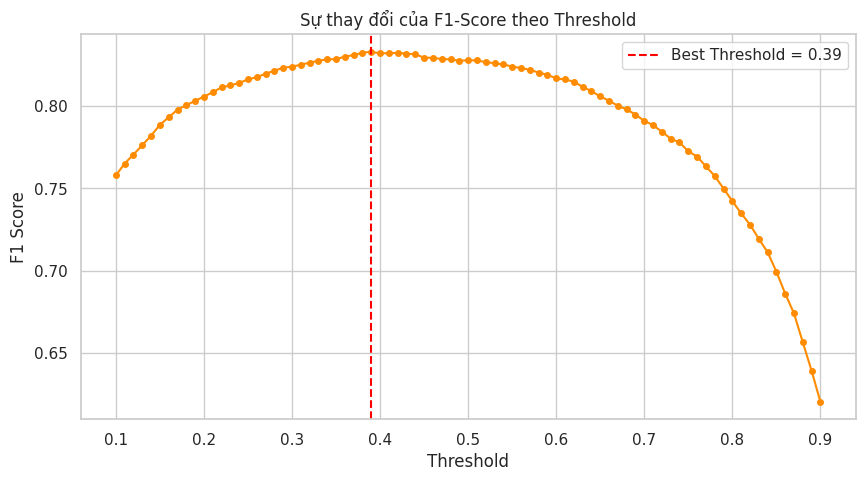

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score
# 1. Lấy xác suất dự đoán cho lớp 1 (Trầm cảm) trên tập validation
y_val_probs = model.predict_proba(X_val)[:, 1]

# 2. Thử các giá trị threshold từ 0.1 đến 0.9
thresholds = np.arange(0.1, 0.91, 0.01)
f1_list = []

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    f1_list.append(f1_score(y_val, y_pred_t))

# 3. Tìm threshold có F1-score cao nhất
best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]
best_f1 = f1_list[best_idx]

print(f"Threshold tốt nhất: {best_threshold:.2f}")
print(f"F1-Score cao nhất trên tập Validation: {best_f1:.4f}")

# 4. Trực quan hóa
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_list, marker='o', linestyle='-', markersize=4, color='darkorange')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.title('Sự thay đổi của F1-Score theo Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

# 5. Áp dụng threshold mới để tạo file submission tối ưu
test_probs = model.predict_proba(X_test)[:, 1]
test_preds_opt = (test_probs >= best_threshold).astype(int)

submission_opt = pd.DataFrame({
    'id': test_df['id'],
    'Depression': test_preds_opt
})
submission_opt.to_csv('submission_optimized.csv', index=False)

# Đánh giá ROC-AUC & Biểu đồ phân phối

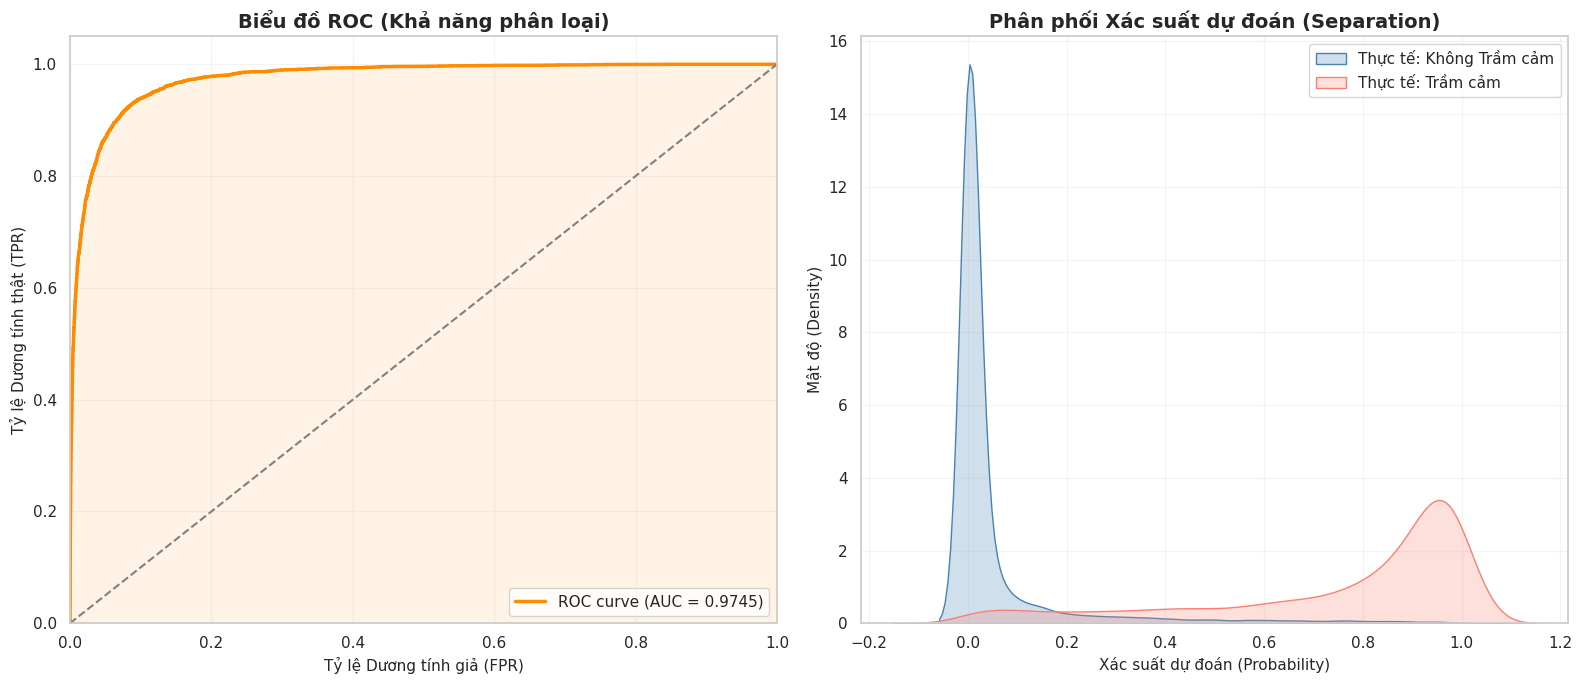

Chỉ số ROC-AUC cuối cùng: 0.9745


In [10]:
# ============================================================
# ĐÁNH GIÁ ROC-AUC & BIỂU ĐỒ PHÂN PHỐI
# ============================================================
from sklearn.metrics import roc_curve, auc

# 1. Lấy xác suất dự đoán
y_val_probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_probs)
roc_auc = auc(fpr, tpr)

# TẠO FIGURE VỚI 2 BIỂU ĐỒ SONG SONG
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- BIỂU ĐỒ 1: ROC CURVE ---
ax[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[0].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
ax[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange') # Tô màu vùng dưới đường cong
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('Tỷ lệ Dương tính giả (FPR)', fontsize=11)
ax[0].set_ylabel('Tỷ lệ Dương tính thật (TPR)', fontsize=11)
ax[0].set_title('Biểu đồ ROC (Khả năng phân loại)', fontsize=14, fontweight='bold')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.2)

# --- BIỂU ĐỒ 2: PROBABILITY DISTRIBUTION (Sự tách biệt giữa 2 lớp) ---
# Biểu đồ này cho thấy mô hình phân tách người bệnh và người khỏe tốt thế nào
sns.kdeplot(y_val_probs[y_val == 0], shade=True, color="steelblue", label="Thực tế: Không Trầm cảm", ax=ax[1], bw_adjust=1)
sns.kdeplot(y_val_probs[y_val == 1], shade=True, color="salmon", label="Thực tế: Trầm cảm", ax=ax[1], bw_adjust=1)
ax[1].set_title('Phân phối Xác suất dự đoán (Separation)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Xác suất dự đoán (Probability)', fontsize=11)
ax[1].set_ylabel('Mật độ (Density)', fontsize=11)
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Chỉ số ROC-AUC cuối cùng: {roc_auc:.4f}")

Phân tích kết quả ROC-AUC
Giá trị AUC: Với giá trị này, mô hình có khả năng phân biệt chính xác một người bị trầm cảm và một người bình thường lên đến hơn 97.45%. Đây là con số rất ấn tượng, cho thấy các đặc trưng như áp lực tài chính, thói quen ăn uống và giấc ngủ cung cấp tín hiệu cực kỳ mạnh.

Đường cong ROC: Đường cong tiến rất sát về góc trên bên trái (Tọa độ 0,1). Điều này chứng tỏ mô hình có thể đạt được Tỷ lệ Dương tính thật (Recall) rất cao trong khi vẫn giữ được Tỷ lệ Dương tính giả ở mức thấp.

Phân tích Biểu đồ Phân phối (Separation Plot)
Khoảng cách giữa hai đỉnh: Có thể thấy đỉnh của nhóm "Trầm cảm" (màu cam) nằm lệch hẳn về phía bên phải (xác suất cao), trong khi nhóm "Không trầm cảm" (màu xanh) nằm về bên trái. Vì 2 đỉnh cách xa nhau, điều này có nghĩa là mô hình biết đưa tỉ lệ những người mắc bệnh về phía xác suất cao (gần 1) và những người không bị bệnh về phía có xác suất thấp (gần 0).

Vùng chồng lấn (Overlap): Vùng mà hai màu xanh và cam đè lên nhau chính là nơi mô hình dễ bị dự đoán nhầm nhất. Diện tích của vùng này khá nhỏ, cho thấy khả năng dự đoán của mô hình khá tốt, không bị nhầm lẫn giữa người mắc bệnh và người không mắc bệnh.

# Độ Quan Trọng Đặc Trưng

Top 15 đặc trưng quan trọng nhất (CatBoost):
                              Feature  Importance
                                  Age   33.664287
Have you ever had suicidal thoughts ?   17.193531
                       Total_Pressure    8.724886
                     Financial Stress    8.282290
                     Work_Sleep_Ratio    4.658858
                     Job Satisfaction    4.273019
      Working Professional or Student    3.865714
                   Total_Satisfaction    3.531194
                       Dietary Habits    3.481237
                           Profession    2.147406
                    Academic Pressure    1.761505
                     Work/Study Hours    1.565474
                               Degree    1.561832
                        Work Pressure    1.248998
                                 City    1.194773


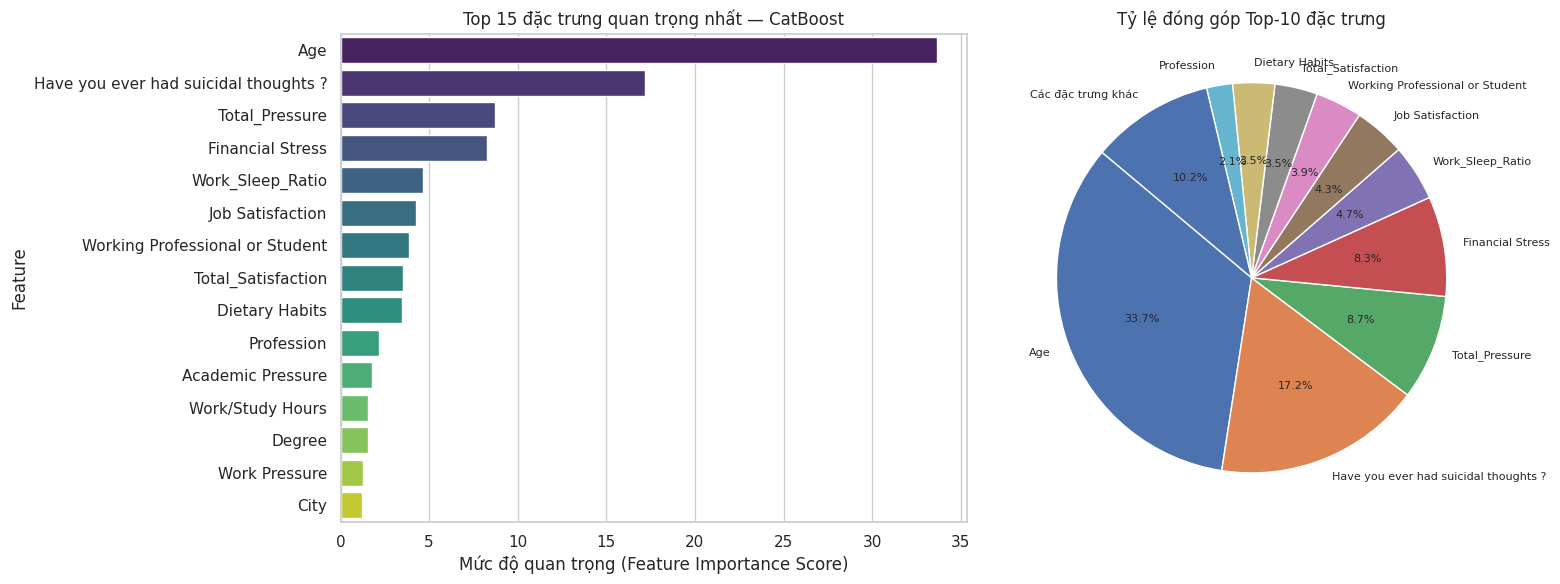


Nhận xét: Các đặc trưng liên quan đến áp lực và suy nghĩ tự tử
thường đứng đầu trong mô hình dự đoán trầm cảm.


In [11]:
# Lấy điểm quan trọng từ mô hình CatBoost đã huấn luyện
feat_imp_df = pd.DataFrame({
    'Feature':    X.columns.tolist(),
    'Importance': model.get_feature_importance()
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 15 đặc trưng quan trọng nhất (CatBoost):")
print(feat_imp_df.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot Top-15
sns.barplot(x='Importance', y='Feature',
            data=feat_imp_df.head(15),
            palette='viridis', ax=axes[0])
axes[0].set_title('Top 15 đặc trưng quan trọng nhất — CatBoost', fontsize=12)
axes[0].set_xlabel('Mức độ quan trọng (Feature Importance Score)')

# Pie chart Top-10 để thấy tỷ lệ đóng góp
top10 = feat_imp_df.head(10)
others = feat_imp_df.iloc[10:]['Importance'].sum()
pie_data   = list(top10['Importance']) + [others]
pie_labels = list(top10['Feature'])   + ['Các đặc trưng khác']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Tỷ lệ đóng góp Top-10 đặc trưng', fontsize=12)

plt.tight_layout()
plt.show()

print("\nNhận xét: Các đặc trưng liên quan đến áp lực và suy nghĩ tự tử")
print("thường đứng đầu trong mô hình dự đoán trầm cảm.")

# Mô Hình LightGBM & Random Forest

In [12]:
# ============================================================
# PHẦN 8: MÔ HÌNH LIGHTGBM & RANDOM FOREST
# ============================================================

# Label-encode các cột phân loại cho LightGBM và RandomForest
# (hai mô hình này không tự xử lý biến phân loại dạng chuỗi như CatBoost)
def encode_cat_features(df_train, df_val, cols):
    """
    Label-encode các cột phân loại.
    Fit trên hợp nhất (union) train+val để tránh lỗi unseen labels.
    """
    df_tr = df_train.copy()
    df_va = df_val.copy()
    for col in cols:
        le = LabelEncoder()
        combined = pd.concat([df_tr[col], df_va[col]]).astype(str)
        le.fit(combined)
        df_tr[col] = le.transform(df_tr[col].astype(str))
        df_va[col] = le.transform(df_va[col].astype(str))
    return df_tr, df_va

X_train_enc, X_val_enc = encode_cat_features(X_train, X_val, cat_features)

# ---- 8.1 LightGBM ----
print("=" * 60)
print("8.1  LIGHTGBM")
print("=" * 60)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(
    X_train_enc, y_train,
    eval_set=[(X_val_enc, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

y_pred_lgbm = lgbm_model.predict(X_val_enc)
acc_lgbm    = accuracy_score(y_val, y_pred_lgbm)
print(f"\nLightGBM — Accuracy: {acc_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm,
                             target_names=['Không trầm cảm', 'Trầm cảm']))

# ---- 8.2 Random Forest ----
print("=" * 60)
print("8.2  RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_enc, y_train)

y_pred_rf = rf_model.predict(X_val_enc)
acc_rf    = accuracy_score(y_val, y_pred_rf)
print(f"\nRandom Forest — Accuracy: {acc_rf:.4f}")
print(classification_report(y_val, y_pred_rf,
                             target_names=['Không trầm cảm', 'Trầm cảm']))

8.1  LIGHTGBM
[100]	valid_0's binary_logloss: 0.155684
[200]	valid_0's binary_logloss: 0.153948

LightGBM — Accuracy: 0.9380
                precision    recall  f1-score   support

Không trầm cảm       0.96      0.97      0.96     23027
      Trầm cảm       0.84      0.81      0.83      5113

      accuracy                           0.94     28140
     macro avg       0.90      0.89      0.89     28140
  weighted avg       0.94      0.94      0.94     28140

8.2  RANDOM FOREST

Random Forest — Accuracy: 0.9364
                precision    recall  f1-score   support

Không trầm cảm       0.95      0.97      0.96     23027
      Trầm cảm       0.85      0.79      0.82      5113

      accuracy                           0.94     28140
     macro avg       0.90      0.88      0.89     28140
  weighted avg       0.94      0.94      0.94     28140



# So Sánh Các Mô Hình

Bảng so sánh hiệu năng các mô hình (tập Validation):


,Accuracy,Precision,Recall,F1-Score
Mô hình,,,,
CatBoost,0.9388,0.9021,0.8889,0.8953
LightGBM,0.9380,0.8994,0.8897,0.8945
RandomForest,0.9364,0.9010,0.8804,0.8902



Mô hình tốt nhất theo F1-Score: CatBoost


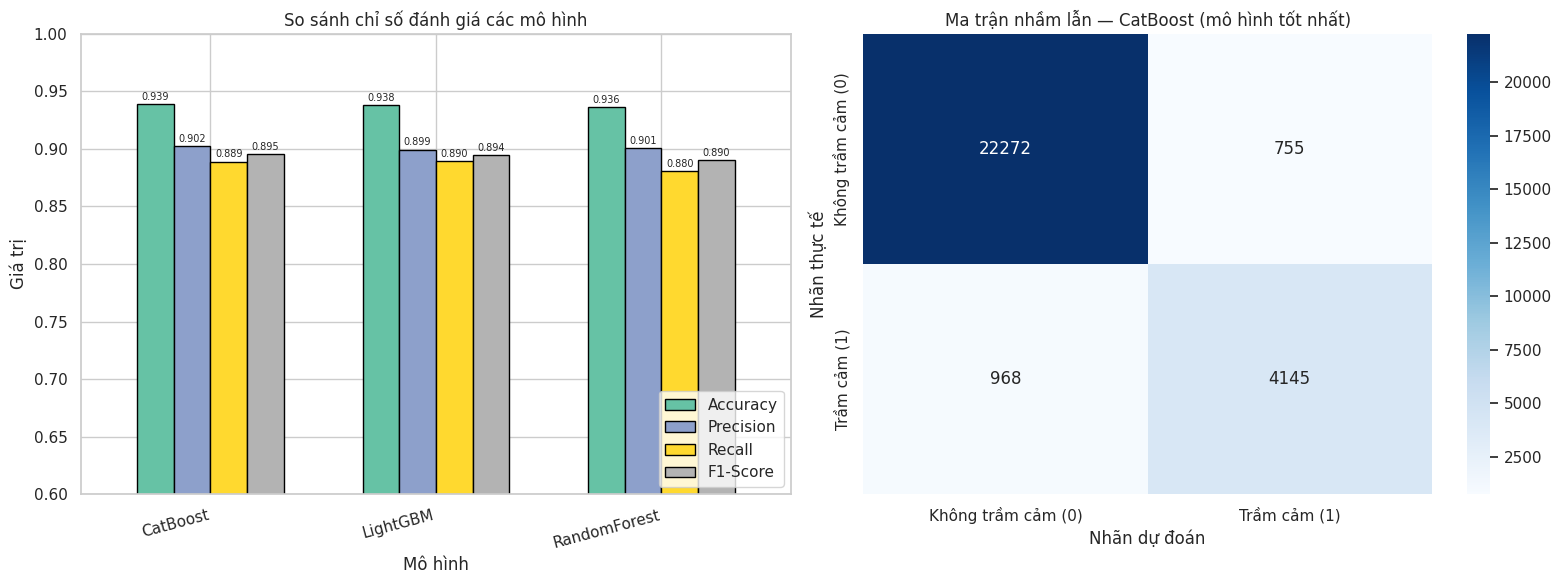

In [13]:
# Thu thập kết quả dự đoán từ tất cả 3 mô hình đã huấn luyện
results = {
    'CatBoost':     y_pred,
    'LightGBM':     y_pred_lgbm,
    'RandomForest': y_pred_rf,
}

# Tính toán các chỉ số đánh giá cho từng mô hình
summary_rows = []
for name, preds in results.items():
    summary_rows.append({
        'Mô hình':   name,
        'Accuracy':  accuracy_score(y_val, preds),
        'Precision': precision_score(y_val, preds, average='macro', zero_division=0),
        'Recall':    recall_score(y_val, preds, average='macro', zero_division=0),
        'F1-Score':  f1_score(y_val, preds, average='macro', zero_division=0),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Mô hình')
print("Bảng so sánh hiệu năng các mô hình (tập Validation):")
display(summary_df.round(4))

best_name = summary_df['F1-Score'].idxmax()
print(f"\nMô hình tốt nhất theo F1-Score: {best_name}")

# ---- Biểu đồ so sánh ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Grouped bar chart các chỉ số
summary_df.plot(kind='bar', ax=axes[0],
                edgecolor='black', width=0.65, colormap='Set2')
axes[0].set_title('So sánh chỉ số đánh giá các mô hình', fontsize=12)
axes[0].set_ylim(0.6, 1.0)
axes[0].set_xticklabels(summary_df.index, rotation=15, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylabel('Giá trị')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', fontsize=7)

# (b) Confusion matrix của mô hình tốt nhất
best_preds = results[best_name]
cm = confusion_matrix(y_val, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Không trầm cảm (0)', 'Trầm cảm (1)'],
            yticklabels=['Không trầm cảm (0)', 'Trầm cảm (1)'])
axes[1].set_title(f'Ma trận nhầm lẫn — {best_name} (mô hình tốt nhất)',
                  fontsize=12)
axes[1].set_xlabel('Nhãn dự đoán')
axes[1].set_ylabel('Nhãn thực tế')

plt.tight_layout()
plt.show()

# Sử dụng Optuna để tìm bộ tham số phù hợp

In [14]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

# 1. Lấy danh sách các cột phân loại
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

def objective(trial):
    param = {
        "objective": "Logloss",
        "depth": trial.suggest_int("depth", 4, 10),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "iterations": trial.suggest_int("iterations", 500, 1500),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        "verbose": False,
        "random_state": 42,
        "task_type": "GPU" # Chạy trên GPU để tăng tốc
    }

    # 2. Khởi tạo mô hình
    model = CatBoostClassifier(**param)
    
    # 3. Huấn luyện
    model.fit(
        X_train, y_train, 
        cat_features=cat_features, 
        eval_set=[(X_val, y_val)], 
        early_stopping_rounds=50, 
        verbose=False
    )

    # 4. Dự đoán và tính điểm
    preds = model.predict(X_val)
    score = f1_score(y_val, preds, average='macro')
    
    return score

# 5. Chạy Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Tham số tốt nhất:", study.best_params)
print(f"Giá trị F1-score tốt nhất: {study.best_value:.4f}")

[I 2026-04-09 17:16:35,666] A new study created in memory with name: no-name-c9d7c39b-09c3-4d82-a4a3-7689299b3a79
[I 2026-04-09 17:17:28,128] Trial 0 finished with value: 0.8965483183082152 and parameters: {'depth': 7, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bernoulli', 'learning_rate': 0.03667345808277504, 'iterations': 649, 'l2_leaf_reg': 0.2328952462830922}. Best is trial 0 with value: 0.8965483183082152.
[I 2026-04-09 17:18:03,087] Trial 1 finished with value: 0.8932139662372236 and parameters: {'depth': 5, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'learning_rate': 0.0060479406777258615, 'iterations': 904, 'l2_leaf_reg': 0.07844374683927352}. Best is trial 0 with value: 0.8965483183082152.
[I 2026-04-09 17:18:36,671] Trial 2 finished with value: 0.8955974058851839 and parameters: {'depth': 4, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'learning_rate': 0.019011817631722407, 'iterations': 1055, 'l2_leaf_reg': 3.9635951530592672}. Best is trial 0 

Tham số tốt nhất: {'depth': 7, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bernoulli', 'learning_rate': 0.03667345808277504, 'iterations': 649, 'l2_leaf_reg': 0.2328952462830922}
Giá trị F1-score tốt nhất: 0.8965


In [15]:
# 1. Lấy tham số tốt nhất
best_params = study.best_params

# 2. Khởi tạo mô hình Final với bộ tham số đó
# Thêm task_type="GPU" nếu bạn muốn chạy nhanh, bỏ đi nếu dùng CPU
final_model = CatBoostClassifier(**best_params, task_type="GPU", verbose=False)

# 3. Huấn luyện lại trên tập Train
final_model.fit(X_train, y_train, cat_features=cat_features)

# 4. Dự đoán trên tập Validation để lấy số liệu thực tế
y_final_pred = final_model.predict(X_val)

# 5. In kết quả đánh giá chi tiết
from sklearn.metrics import classification_report, confusion_matrix
print("KẾT QUẢ MÔ HÌNH SAU TỐI ƯU:")
print(classification_report(y_val, y_final_pred))

KẾT QUẢ MÔ HÌNH SAU TỐI ƯU:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23027
           1       0.85      0.81      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.90     28140
weighted avg       0.94      0.94      0.94     28140



# Kiểm Tra Chéo (Cross-Validation)

Đang chạy 10-Fold Stratified Cross-Validation với CatBoost (tham số tối ưu)...
(Quá trình này mất khoảng vài phút)

  Fold 1: Accuracy = 0.9382
  Fold 2: Accuracy = 0.9412
  Fold 3: Accuracy = 0.9382
  Fold 4: Accuracy = 0.9380
  Fold 5: Accuracy = 0.9405
  Fold 6: Accuracy = 0.9394
  Fold 7: Accuracy = 0.9403
  Fold 8: Accuracy = 0.9422
  Fold 9: Accuracy = 0.9398
  Fold 10: Accuracy = 0.9393

Kết quả Cross-Validation (10 folds):
  Accuracy trung bình : 0.9397
  Độ lệch chuẩn       : 0.0013
  Accuracy lớn nhất   : 0.9422

→ Độ lệch chuẩn nhỏ cho thấy mô hình ổn định và không bị overfit.


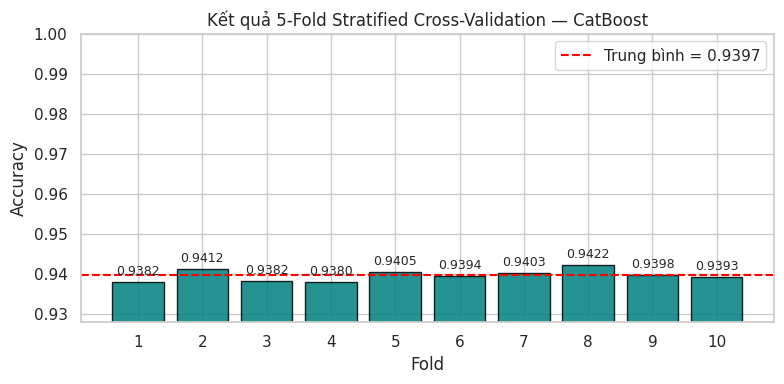

In [16]:
# Đánh giá tính ổn định của mô hình CatBoost qua 10 fold

print("Đang chạy 10-Fold Stratified Cross-Validation với CatBoost (tham số tối ưu)...")
print("(Quá trình này mất khoảng vài phút)\n")

best_params = study.best_params

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_fold_tr, X_fold_va = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_tr, y_fold_va = y.iloc[train_idx], y.iloc[val_idx]

    fold_model = CatBoostClassifier(
        **best_params,
        cat_features=cat_features,
        task_type='GPU',
        verbose=0,
        random_seed=42
    )
    fold_model.fit(X_fold_tr, y_fold_tr)

    fold_pred = fold_model.predict(X_fold_va)
    fold_acc  = accuracy_score(y_fold_va, fold_pred)
    cv_scores.append(fold_acc)
    print(f"  Fold {fold}: Accuracy = {fold_acc:.4f}")

print(f"\nKết quả Cross-Validation (10 folds):")
print(f"  Accuracy trung bình : {np.mean(cv_scores):.4f}")
print(f"  Độ lệch chuẩn       : {np.std(cv_scores):.4f}")
print(f"  Accuracy lớn nhất   : {np.max(cv_scores):.4f}")
print("\n→ Độ lệch chuẩn nhỏ cho thấy mô hình ổn định và không bị overfit.")

# Biểu đồ kết quả CV
plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, 11), cv_scores,
               color='teal', edgecolor='black', alpha=0.85)
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', linewidth=1.5,
            label=f'Trung bình = {np.mean(cv_scores):.4f}')
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.title('Kết quả 5-Fold Stratified Cross-Validation — CatBoost', fontsize=12)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, 11))
plt.ylim(min(cv_scores) - 0.01, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# Kết Luận & Hướng Phát Triển

------------------------------
BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH
------------------------------


,Mô hình,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,CatBoost,0.9388,0.9021,0.8889,0.8953
1,LightGBM,0.9380,0.8994,0.8897,0.8945
2,RandomForest,0.9364,0.9010,0.8804,0.8902


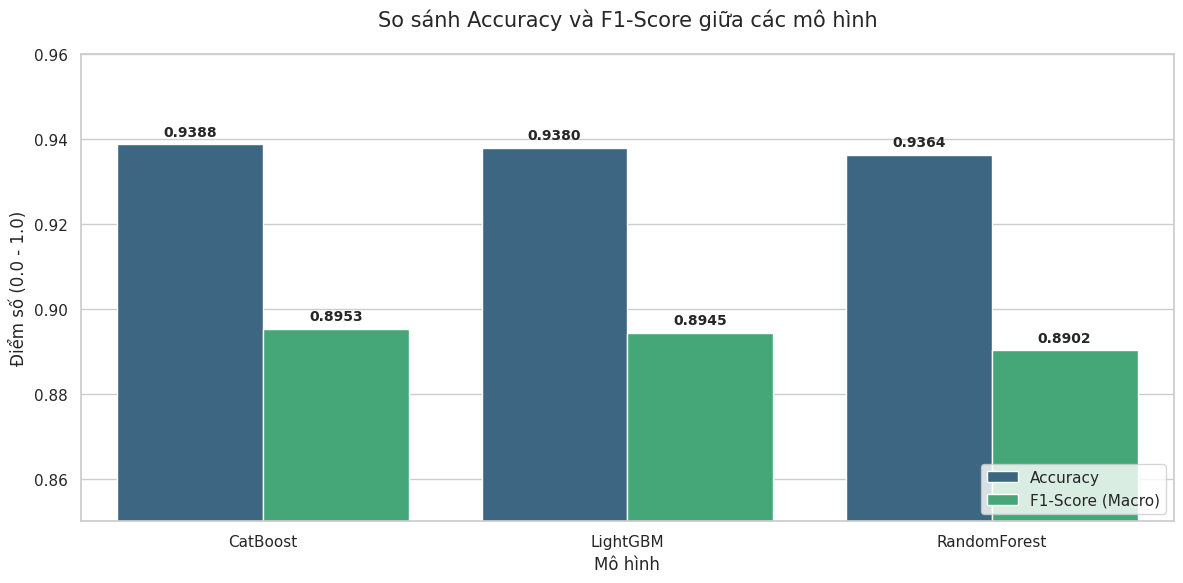

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Thu thập kết quả dự đoán từ các mô hình đã chạy
# Giả định tên biến dự đoán trong notebook của bạn là:
# y_pred (CatBoost), y_pred_lgbm (LightGBM), y_pred_rf (Random Forest)
results_map = {
    'CatBoost': y_pred,
    'LightGBM': y_pred_lgbm,
    'RandomForest': y_pred_rf
}

# 2. Tính toán các chỉ số
summary_data = []
for name, preds in results_map.items():
    summary_data.append({
        'Mô hình': name,
        'Accuracy': accuracy_score(y_val, preds),
        'Precision (Macro)': precision_score(y_val, preds, average='macro'),
        'Recall (Macro)': recall_score(y_val, preds, average='macro'),
        'F1-Score (Macro)': f1_score(y_val, preds, average='macro')
    })

# Tạo DataFrame để in bảng
df_results = pd.DataFrame(summary_data)

# --- PHẦN 1: IN BẢNG SỐ LIỆU ---
print("-" * 30)
print("BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH")
print("-" * 30)
display(df_results.round(4))

# --- PHẦN 2: VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Chuyển dữ liệu sang dạng 'long format' để vẽ với seaborn dễ hơn
df_plot = df_results.melt(id_vars='Mô hình', value_vars=['Accuracy', 'F1-Score (Macro)'], 
                          var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_plot, x='Mô hình', y='Score', hue='Metric', palette='viridis')

# Tinh chỉnh biểu đồ
plt.title('So sánh Accuracy và F1-Score giữa các mô hình', fontsize=15, pad=20)
plt.ylim(0.85, 0.96)
plt.ylabel('Điểm số (0.0 - 1.0)')
plt.legend(loc='lower right')

# Thêm số liệu cụ thể lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Kết luận:

Dựa trên quá trình khám phá dữ liệu (EDA) và huấn luyện các mô hình học máy, chúng ta có thể rút ra các kết luận quan trọng sau:

Hiệu năng mô hình: Trong số ba thuật toán đã thử nghiệm, CatBoost cho kết quả tốt nhất với các chỉ số vượt trội trên tập Validation:

Accuracy (Độ chính xác): 93.88%

F1-Score (Macro): ~89.53%

Khả năng nhận diện lớp Trầm cảm (Class 1): Đạt F1-score khoảng 0.83 (sau khi tối ưu ngưỡng threshold lên 0.39).

Sau khi chạy mô hình với tham số tối ưu của Optuna, Accuracy thậm chí chạm mốc 94,22% và trung bình cũng rất cao ~94%.

Các yếu tố ảnh hưởng chính (Feature Importance):

Tâm lý & Di truyền: Ý nghĩ tự tử (Have you ever had suicidal thoughts?) và Tiền sử gia đình (Family History of Mental Illness) là hai chỉ số có mối tương quan mạnh nhất với tình trạng trầm cảm.

Áp lực & Hài lòng: Áp lực học tập/công việc (Academic/Work Pressure) càng cao và mức độ hài lòng (Study/Job Satisfaction) càng thấp thì nguy cơ trầm cảm càng tăng rõ rệt.

Lối sống: Thời gian ngủ (Sleep Duration) ít và thói quen ăn uống không lành mạnh (Dietary Habits) cũng đóng vai trò đáng kể trong việc dự báo.

Xử lý dữ liệu: Việc kết hợp đặc trưng (Feature Engineering) như tạo chỉ số Work_Sleep_Ratio và Total_Pressure đã giúp mô hình nắm bắt tốt hơn các trạng thái căng thẳng của đối tượng khảo sát.

Hướng phát triển:

Để cải thiện độ chính xác và tính ứng dụng của mô hình trong thực tế, dự án có thể phát triển theo các hướng sau:

- Mở rộng thử nghiệm: Thử với nhiều mô hình hơn để kiểm tra các mô hình phù hợp nhất với dữ liệu, cho Accuracy và F1-score cao hơn.

- Cải thiện chất lượng dữ liệu: Thu thập thêm dữ liệu thực tế từ nhiều nguồn khác nhau để giảm thiểu sai số do dữ liệu giả lập. Áp dụng các kỹ thuật xử lý dữ liệu thiếu (Imputation) tiên tiến hơn thay vì chỉ dùng Median/Mode.

- Tối ưu hóa mô hình: Thực hiện Hyperparameter Tuning sâu hơn bằng Optuna cho mô hình CatBoost để đẩy F1-score lên cao hơn nữa.

- Triển khai ứng dụng (Deployment): Xây dựng một ứng dụng web hoặc chatbot đơn giản sử dụng mô hình này để giúp người dùng tự sàng lọc sức khỏe tâm thần ban đầu.

- Phân tích sâu hơn: Nghiên cứu thêm về tác động của các biến nhân khẩu học như City (Thành phố) hoặc Profession (Nghề nghiệp) cụ thể để có những khuyến nghị sức khỏe phù hợp cho từng nhóm đối tượng.